# Project 3
### by Oleg Kushnir
##### For this project, I am utilizing a custom-built database that I personally maintain and update on a weekly basis throughout the season, sourcing the data directly from the official Euroleague website.


#### Analyzing the impact of home-court advantage on team success and performance in Euroleague
#### Research Questions:
1. How much higher is the win probability at home compared to away games? 
2. Does playing on the home court affect the scoring output (total points) of the team?
3. How does the home-court advantage influence shooting percentages (specifically for 2-pointers and 3-pointers)?

In [1]:
# Connection to the database and data manipulation libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Connection to the database and loading the datasets 
stats = pd.read_csv('H:\\Data Analyst\\Projects\\3_Project_Python\\Project_Euroleague\\Matches_Stat.csv')
matches = pd.read_csv('H:\\Data Analyst\\Projects\\3_Project_Python\\Project_Euroleague\\Matches.csv')
teams = pd.read_csv('H:\\Data Analyst\\Projects\\3_Project_Python\\Project_Euroleague\\Teams.csv')

#### Before any manipulations, lets see what we have in dataset by using functions like (head, tail, info & describe)

In [3]:
# First of all lets understand the structure of the datasets
stats.head()


,Stats_ID,Match_ID,Team_ID,2 pt made,2 pt attemps,3 pt made,3 pt attemps,1 pt made,1 pt attemps,offensive rebound,...,assists,steals,turnovers,blocks made,blocks received,fouls committed,fouls drawn,points made,points received,pir
0,1,1,11,25,41,13,24,14,15,9,...,19,8,12,5,1,19,16,103,87,118
1,2,1,7,22,38,10,25,13,17,14,...,18,9,15,1,5,16,19,87,103,95
2,3,2,6,23,45,11,20,10,12,10,...,21,5,8,0,2,19,16,89,76,101
3,4,2,16,19,43,7,18,17,21,15,...,16,4,13,2,0,16,19,76,89,83
4,5,3,1,23,37,9,29,12,15,14,...,15,6,14,1,3,21,20,85,78,92


In [4]:
# Understanding the structure of the datasets
stats.tail() 

,Stats_ID,Match_ID,Team_ID,2 pt made,2 pt attemps,3 pt made,3 pt attemps,1 pt made,1 pt attemps,offensive rebound,...,assists,steals,turnovers,blocks made,blocks received,fouls committed,fouls drawn,points made,points received,pir
633,634,317,17,21,43,9,29,16,20,18,...,17,4,9,3,4,18,18,85,87,91
634,635,318,14,19,29,10,27,14,17,6,...,19,6,14,2,4,19,19,82,74,97
635,636,318,5,21,39,7,27,11,15,12,...,22,8,12,4,2,19,16,74,82,85
636,637,319,3,21,38,10,28,13,23,11,...,22,3,11,3,1,24,22,85,89,89
637,638,319,13,23,39,8,29,19,22,13,...,25,6,10,1,3,22,24,89,85,111


In [5]:
stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Stats_ID           638 non-null    int64
 1   Match_ID           638 non-null    int64
 2   Team_ID            638 non-null    int64
 3   2 pt made          638 non-null    int64
 4   2 pt attemps       638 non-null    int64
 5   3 pt made          638 non-null    int64
 6   3 pt attemps       638 non-null    int64
 7   1 pt made          638 non-null    int64
 8   1 pt attemps       638 non-null    int64
 9   offensive rebound  638 non-null    int64
 10  defensive rebound  638 non-null    int64
 11  assists            638 non-null    int64
 12  steals             638 non-null    int64
 13  turnovers          638 non-null    int64
 14  blocks made        638 non-null    int64
 15  blocks received    638 non-null    int64
 16  fouls committed    638 non-null    int64
 17  fouls drawn        638 non-

In [6]:
# Understanding if I have NuN values in stats dataset
print(stats.isnull().values.any())

False


In [7]:
matches.head()

,Season_ID,Round_ID,Match_ID,HomeTeam_ID,GuestTeam_ID
0,26,1,1,11.0,7.0
1,26,1,2,6.0,16.0
2,26,1,3,1.0,13.0
3,26,1,4,5.0,4.0
4,26,1,5,14.0,8.0


In [8]:
# In the last line 319 I found NaN in the Home_Team_ID & Guest_Team_ID columns! So I will remove these rows as they are not useful for our analysis.
# Also in 'stats' datasets I saw that there is last "Match_ID" was 319, so I will remove the row under index 319 in matches dataset.  
matches.tail()

,Season_ID,Round_ID,Match_ID,HomeTeam_ID,GuestTeam_ID
315,26,32,316,10.0,4.0
316,26,32,317,20.0,17.0
317,26,32,318,14.0,5.0
318,26,32,319,3.0,13.0
319,26,32,320,NaN,NaN


In [9]:
# Removing the rows with NaN values in Home_Team_ID & Guest_Team_ID columns with index 319
matches = matches.drop(index=319)

In [10]:
matches.tail()

,Season_ID,Round_ID,Match_ID,HomeTeam_ID,GuestTeam_ID
314,26,32,315,15.0,16.0
315,26,32,316,10.0,4.0
316,26,32,317,20.0,17.0
317,26,32,318,14.0,5.0
318,26,32,319,3.0,13.0


In [11]:
# Understanding if I have NuN values in matches dataset
print(matches.isnull().values.any())

False


In [12]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Season_ID     319 non-null    int64  
 1   Round_ID      319 non-null    int64  
 2   Match_ID      319 non-null    int64  
 3   HomeTeam_ID   319 non-null    float64
 4   GuestTeam_ID  319 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 12.6 KB


In [13]:
# Understanding the structure of the datasets
teams.head()

,Team_ID,Team_Name
0,1,Anadolu Efes
1,2,AS Monaco
2,3,Asvel
3,4,Armani Milan
4,5,Crvena Zvezda


In [14]:
teams.tail()

,Team_ID,Team_Name
15,16,Partizan
16,17,Real Madrid
17,18,Valencia
18,19,Virtus
19,20,Zalgiris


In [15]:
teams.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Team_ID    20 non-null     int64
 1   Team_Name  20 non-null     str  
dtypes: int64(1), str(1)
memory usage: 452.0 bytes


In [16]:
# Technical check for missing values
print(matches.isnull().values.any())

False


### 1. How much higher is the win probability at home compared to away games? 


In [17]:
stats.head()

,Stats_ID,Match_ID,Team_ID,2 pt made,2 pt attemps,3 pt made,3 pt attemps,1 pt made,1 pt attemps,offensive rebound,...,assists,steals,turnovers,blocks made,blocks received,fouls committed,fouls drawn,points made,points received,pir
0,1,1,11,25,41,13,24,14,15,9,...,19,8,12,5,1,19,16,103,87,118
1,2,1,7,22,38,10,25,13,17,14,...,18,9,15,1,5,16,19,87,103,95
2,3,2,6,23,45,11,20,10,12,10,...,21,5,8,0,2,19,16,89,76,101
3,4,2,16,19,43,7,18,17,21,15,...,16,4,13,2,0,16,19,76,89,83
4,5,3,1,23,37,9,29,12,15,14,...,15,6,14,1,3,21,20,85,78,92


In [18]:
teams.head()

,Team_ID,Team_Name
0,1,Anadolu Efes
1,2,AS Monaco
2,3,Asvel
3,4,Armani Milan
4,5,Crvena Zvezda


In [19]:
matches.head()

,Season_ID,Round_ID,Match_ID,HomeTeam_ID,GuestTeam_ID
0,26,1,1,11.0,7.0
1,26,1,2,6.0,16.0
2,26,1,3,1.0,13.0
3,26,1,4,5.0,4.0
4,26,1,5,14.0,8.0


In [20]:
# Merging the datasets to create a comprehensive dataframe for analysis
df = pd.merge(matches, stats, on='Match_ID', how='left')

In [21]:
df

,Season_ID,Round_ID,Match_ID,HomeTeam_ID,GuestTeam_ID,Stats_ID,Team_ID,2 pt made,2 pt attemps,3 pt made,...,assists,steals,turnovers,blocks made,blocks received,fouls committed,fouls drawn,points made,points received,pir
0,26,1,1,11.0,7.0,1,11,25,41,13,...,19,8,12,5,1,19,16,103,87,118
1,26,1,1,11.0,7.0,2,7,22,38,10,...,18,9,15,1,5,16,19,87,103,95
2,26,1,2,6.0,16.0,3,6,23,45,11,...,21,5,8,0,2,19,16,89,76,101
3,26,1,2,6.0,16.0,4,16,19,43,7,...,16,4,13,2,0,16,19,76,89,83
4,26,1,3,1.0,13.0,5,1,23,37,9,...,15,6,14,1,3,21,20,85,78,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633,26,32,317,20.0,17.0,634,17,21,43,9,...,17,4,9,3,4,18,18,85,87,91
634,26,32,318,14.0,5.0,635,14,19,29,10,...,19,6,14,2,4,19,19,82,74,97
635,26,32,318,14.0,5.0,636,5,21,39,7,...,22,8,12,4,2,19,16,74,82,85
636,26,32,319,3.0,13.0,637,3,21,38,10,...,22,3,11,3,1,24,22,85,89,89


In [22]:
# Home team identification and adding new column 'homeTeam'
df['homeTeam'] = df['Team_ID'] == df['HomeTeam_ID'] 

In [23]:
df

,Season_ID,Round_ID,Match_ID,HomeTeam_ID,GuestTeam_ID,Stats_ID,Team_ID,2 pt made,2 pt attemps,3 pt made,...,steals,turnovers,blocks made,blocks received,fouls committed,fouls drawn,points made,points received,pir,homeTeam
0,26,1,1,11.0,7.0,1,11,25,41,13,...,8,12,5,1,19,16,103,87,118,True
1,26,1,1,11.0,7.0,2,7,22,38,10,...,9,15,1,5,16,19,87,103,95,False
2,26,1,2,6.0,16.0,3,6,23,45,11,...,5,8,0,2,19,16,89,76,101,True
3,26,1,2,6.0,16.0,4,16,19,43,7,...,4,13,2,0,16,19,76,89,83,False
4,26,1,3,1.0,13.0,5,1,23,37,9,...,6,14,1,3,21,20,85,78,92,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633,26,32,317,20.0,17.0,634,17,21,43,9,...,4,9,3,4,18,18,85,87,91,False
634,26,32,318,14.0,5.0,635,14,19,29,10,...,6,14,2,4,19,19,82,74,97,True
635,26,32,318,14.0,5.0,636,5,21,39,7,...,8,12,4,2,19,16,74,82,85,False
636,26,32,319,3.0,13.0,637,3,21,38,10,...,3,11,3,1,24,22,85,89,89,True


In [24]:
# Adding a new column that represents final status of the matches (Win or Lose)
df['win'] = df['points made'] > df['points received']

In [25]:
df


,Season_ID,Round_ID,Match_ID,HomeTeam_ID,GuestTeam_ID,Stats_ID,Team_ID,2 pt made,2 pt attemps,3 pt made,...,turnovers,blocks made,blocks received,fouls committed,fouls drawn,points made,points received,pir,homeTeam,win
0,26,1,1,11.0,7.0,1,11,25,41,13,...,12,5,1,19,16,103,87,118,True,True
1,26,1,1,11.0,7.0,2,7,22,38,10,...,15,1,5,16,19,87,103,95,False,False
2,26,1,2,6.0,16.0,3,6,23,45,11,...,8,0,2,19,16,89,76,101,True,True
3,26,1,2,6.0,16.0,4,16,19,43,7,...,13,2,0,16,19,76,89,83,False,False
4,26,1,3,1.0,13.0,5,1,23,37,9,...,14,1,3,21,20,85,78,92,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633,26,32,317,20.0,17.0,634,17,21,43,9,...,9,3,4,18,18,85,87,91,False,False
634,26,32,318,14.0,5.0,635,14,19,29,10,...,14,2,4,19,19,82,74,97,True,True
635,26,32,318,14.0,5.0,636,5,21,39,7,...,12,4,2,19,16,74,82,85,False,False
636,26,32,319,3.0,13.0,637,3,21,38,10,...,11,3,1,24,22,85,89,89,True,False


In [26]:
# Technical check for missing values
print("Missing values in dataset:")
print(df.isnull().sum())

Missing values in dataset:
Season_ID            0
Round_ID             0
Match_ID             0
HomeTeam_ID          0
GuestTeam_ID         0
Stats_ID             0
Team_ID              0
2 pt made            0
2 pt attemps         0
3 pt made            0
3 pt attemps         0
1 pt made            0
1 pt attemps         0
offensive rebound    0
defensive rebound    0
assists              0
steals               0
turnovers            0
blocks made          0
blocks received      0
fouls committed      0
fouls drawn          0
points made          0
points received      0
pir                  0
homeTeam             0
win                  0
dtype: int64


In [27]:
#Calculate the sum of wins only in home rows and divide by the number of unique matches
home_wins = df[df['homeTeam'] == True]['win'].sum()

In [28]:
home_wins

np.int64(198)

In [29]:
total_matches = df['Match_ID'].nunique()

In [30]:
total_matches

319

In [31]:
# Calculating the home win percentage
home_win_percentage = (home_wins / total_matches) * 100

In [32]:
home_win_percentage

np.float64(62.06896551724138)

In [33]:
home_win_percentage = round(home_win_percentage, 2)
home_win_percentage

np.float64(62.07)

In [34]:
home_losses = df[df['homeTeam'] == False]['win'].sum()
home_losses

np.int64(121)

In [35]:
# Calculating the home loses percentage
home_losses_percentage = (home_losses / total_matches) * 100
home_losses_percentage

np.float64(37.93103448275862)

In [36]:
home_losses_percentage = round(home_losses_percentage, 2)
home_losses_percentage

np.float64(37.93)

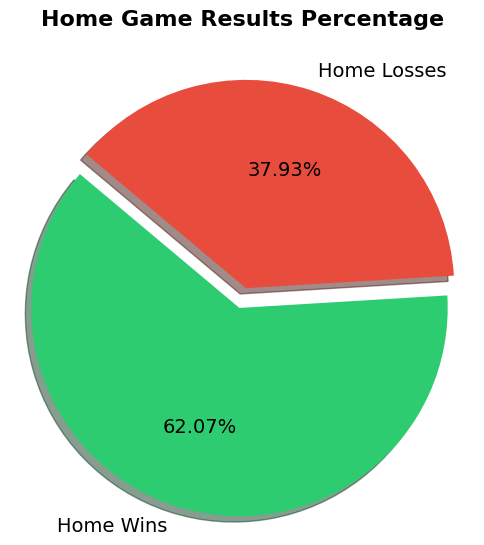

In [37]:
# Visualisation of home games results
plt.figure(figsize=(6, 6))
plt.pie([62.07, 37.93], explode=(0.1, 0), labels=['Home Wins', 'Home Losses'], colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%', shadow=True, startangle=140, textprops={'fontsize': 14})
plt.title('Home Game Results Percentage', fontsize=16, fontweight='bold', pad=30)
plt.axis('equal')
plt.show()

### 2. Does playing on the home court affect the scoring output (total points) of the team?

In [38]:
# Column name check 
total_point_df = df[['homeTeam', 'points made', 'points received']]
total_point_df

,homeTeam,points made,points received
0,True,103,87
1,False,87,103
2,True,89,76
3,False,76,89
4,True,85,78
...,...,...,...
633,False,85,87
634,True,82,74
635,False,74,82
636,True,85,89


In [39]:
# Calculating the average points scored by home and away teams
homeTeam_Points = df[df['homeTeam'] == True]['points made'].mean()
visitTeam_Points = df[df['homeTeam'] == False]['points made'].mean()
print(homeTeam_Points, visitTeam_Points)

87.26959247648902 84.11598746081505


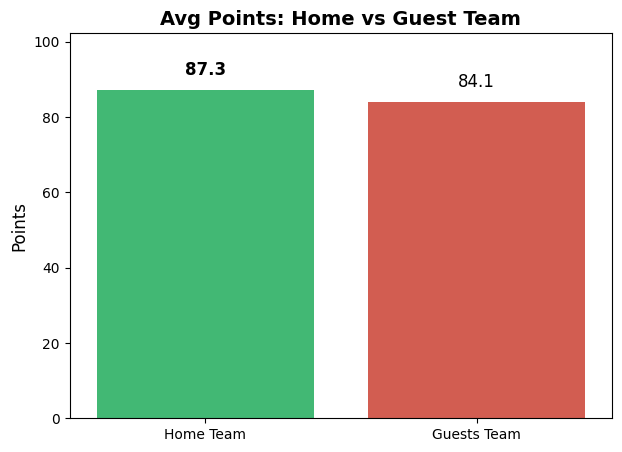

In [40]:
# Visualisation of home teams avg total points vs guests teams
plt.figure(figsize=(7, 5))
sns.barplot(x=['Home Team', 'Guests Team'], y=[homeTeam_Points, visitTeam_Points], hue=['Home Team', 'Guests Team'], palette=['#2ecc71', '#e74c3c'], legend=False)
home_text = f"{homeTeam_Points:.1f}"
away_text = f"{visitTeam_Points:.1f}"
plt.text(0, homeTeam_Points + 4, home_text, ha='center', fontsize=12, fontweight='bold')
plt.text(1, visitTeam_Points + 4, away_text, ha='center', fontsize=12)
plt.title('Avg Points: Home vs Guest Team', fontsize=14, weight='bold')
plt.ylabel('Points', fontsize=12)
plt.xlabel('')
plt.ylim(0, max([homeTeam_Points, visitTeam_Points]) + 15)
plt.show()


##### 3. How does the home-court advantage influence shooting percentages (specifically for 2-pointers and 3-pointers)?

In [41]:
# Home teams shooting performance vs guests teams
home_games = df[df['homeTeam'] == True]
fg2_percentage_home = (home_games['2 pt made'].sum() / home_games['2 pt attemps'].sum()) * 100
fg3_percentage_home = (home_games['3 pt made'].sum() / home_games['3 pt attemps'].sum()) * 100

# Guests teams shooting performance
guests_games = df[df['homeTeam'] == False]
fg2_percentage_guests = (guests_games['2 pt made'].sum() / guests_games['2 pt attemps'].sum()) * 100
fg3_percentage_guests = (guests_games['3 pt made'].sum() / guests_games['3 pt attemps'].sum()) * 100

# Avg of 2pt and 3pt percentage of home games & guests game
home_shooting_avg = (fg2_percentage_home + fg3_percentage_home) / 2
guests_shooting_avg = (fg2_percentage_guests + fg3_percentage_guests) / 2 
print(f"Home shooting 2pt {round(fg2_percentage_home), 1} vs guests {round(fg2_percentage_guests), 1}")
print(f"Home shooting 3pt {round(fg3_percentage_home), 1} vs guests {round(fg3_percentage_guests), 1}")
print(f"Home shooting avg {round(home_shooting_avg, 1)} vs guests {round(guests_shooting_avg, 1)}")  

Home shooting 2pt (56, 1) vs guests (55, 1)
Home shooting 3pt (36, 1) vs guests (35, 1)
Home shooting avg 46.3 vs guests 45.1


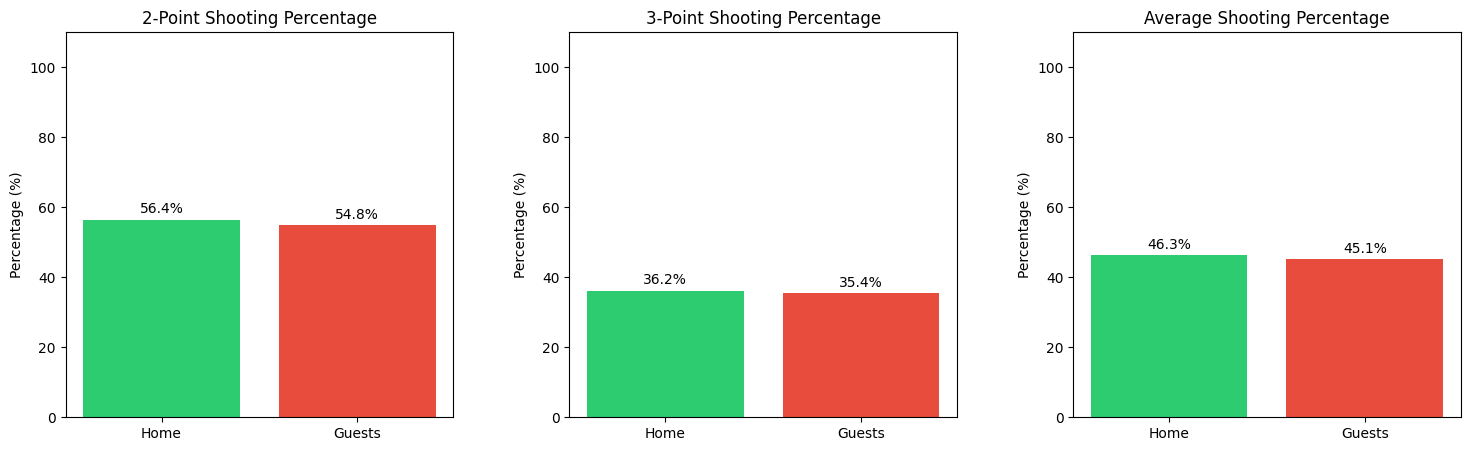

In [42]:
# Visualisation of home teams shooting performance vs guests teams
fig = plt.figure(figsize=(18, 5))
# 2pt shooting
plt.subplot(1, 3, 1)
x_labels = ['Home', 'Guests']
y_values1 = [fg2_percentage_home, fg2_percentage_guests]

plt.bar(x_labels, y_values1, color=['#2ecc71', '#e74c3c'])
for index, value in enumerate(y_values1):
    plt.text(index, value + 1, f"{value:.1f}%", ha='center', va='bottom')
plt.title('2-Point Shooting Percentage')
plt.ylabel('Percentage (%)')
plt.ylim(0, 110)

# 3pt shooting home vs guests
plt.subplot(1, 3, 2)
y_values2 = [fg3_percentage_home, fg3_percentage_guests]

plt.bar(x_labels, y_values2, color=['#2ecc71', '#e74c3c'])
for index, value in enumerate(y_values2):
    plt.text(index, value + 1, f"{value:.1f}%", ha='center', va='bottom')

plt.title('3-Point Shooting Percentage')
plt.ylabel('Percentage (%)')
plt.ylim(0, 110)


# Shooting AVG home team vs guests team
plt.subplot(1, 3, 3)
y_values3 = [home_shooting_avg, guests_shooting_avg]

plt.bar(x_labels, y_values3, color=['#2ecc71', '#e74c3c'])
for index, value in enumerate(y_values3):
    plt.text(index, value + 1, f"{value:.1f}%", ha='center', va='bottom')

plt.title('Average Shooting Percentage')
plt.ylabel('Percentage (%)')
plt.ylim(0, 110)

fig.subplots_adjust(wspace=0.3)
plt.show()

## Conclusions

1. Win Probability: As demonstrated by the analysis, the win percentage for home games is significantly higher than for away games (62% vs. 38%). This reinforces the concept that the home arena acts as a "6th player" on the court, providing a substantial competitive edge.

2. Scoring Output: The offensive performance of the home team also proved to be superior, scoring an average of 3 points more per game compared to the visiting teams.

3. Shooting Accuracy: Shooting efficiency is notably better for the home team. This can be attributed to several factors, including familiarity with their own rims, lighting, and arena interior, as well as a positive psychological impact from the home crowd.

## Practical Recommendations for Coaches

1. Protecting the Home Court and Environmental Conditioning:
It is crucial to understand that home losses are critical to season standings. The primary objective should be a "zero home losses" policy. To better prepare for away games, coaches should introduce environmental variability during pre-trip practices. This includes holding at least one or two sessions in a different facility or intentionally altering the home gym's layout (moving equipment, adding unfamiliar visual markers) to disrupt visual comfort and build player adaptability.

2. Scenario-Based Scrimmaging (Handicaps):
To build mental resilience, all pre-away game scrimmages should start with a point deficit for the starting unit (e.g., beginning at -3 points). Conversely, before home games, the starters should be given a point lead (e.g., +3 points) to practice maintaining momentum and controlling the game from a position of strength.

3. Defensive Focus and Psychological Readiness:
Special emphasis must be placed on defensive cohesion during road games. Teams should drill defensive rotations extensively and be psychologically prepared for the opponent’s elevated shooting percentages. Success on the road depends on the ability to remain composed and disciplined even when the home crowd fuels the opponent’s rhythm.